# 05 — Full EMRI Waveform Generation

This notebook demonstrates the top-level `KerrEccentricEquatorialWaveform` API.

**Topics:**
- Generating $h_+$ and $h_\times$ with a single API call
- The five-stage pipeline (data → trajectory → mode selection → amplitudes → summation)
- Harmonic frequency tracks in the time–frequency plane
- Parameter variation: spin, mass ratio, eccentricity

---

## Pipeline Overview

```
KerrEccentricEquatorialWaveform
  │
  ├─ [init] load_flux_data   →  JAX CubicSpline3D interpolators for Ė, L̇
  ├─ [init] load_amplitude_data  →  raw HDF5 B-spline coefficients (6993 modes)
  │
  └─ __call__(M, μ, a, p₀, e₀, …)
       ├─ EMRIInspiral  →  (t, p, e, Φφ, Φθ, Φr)  [JAX; JIT]
       ├─ select_modes  →  mode indices above power threshold
       ├─ AmplitudeInterpolator.evaluate  →  A[t, mode]  [scipy/CPU]
       ├─ get_ylms_for_modes  →  Y[mode]  [numpy]
       └─ ModeSum  →  h(t) = Σ Y·A·e^{-iΦ}  [JAX; JIT]
```

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import time

jax.config.update("jax_enable_x64", True)

from dotenv import load_dotenv
load_dotenv()
DATA_DIR = os.getenv("FEW_DATA_DIR")
print(f"FEW_DATA_DIR = {DATA_DIR}")

from fewtrax import KerrEccentricEquatorialWaveform

print("Building waveform generator…")
t0 = time.perf_counter()
wf = KerrEccentricEquatorialWaveform(
    data_dir=DATA_DIR,
    mode_selection_threshold=1e-5,
    dense_steps=150,
)
print(f"Loaded in {time.perf_counter() - t0:.1f} s")

FEW_DATA_DIR = /Users/bertd/Documents/PhD/LISA/Codes/FastEMRIWaveforms/src/few/data
Building waveform generator…
Loaded in 36.3 s


## 5.1  Generating a Waveform

The `__call__` method accepts the same parameter set as FEW's `FastKerrEccentricEquatorialFlux`.

In [2]:
# Reference parameter set
params = dict(
    M       = 1e6,   # primary BH mass       [M_sun]
    mu      = 10.0,  # secondary mass        [M_sun]
    a       = 0.7,   # dimensionless spin
    p0      = 12.0,  # initial semi-latus    [M]
    e0      = 0.4,   # initial eccentricity
    x0      = 1.0,   # prograde
    dist    = 1.0,   # luminosity distance   [Gpc]
    qS      = 0.3,   # source sky colatitude [rad]
    phiS    = 1.0,   # source sky longitude  [rad]
    qK      = 0.8,   # spin colatitude       [rad]
    phiK    = 0.5,   # spin longitude        [rad]
    Phi_phi0   = 1.0,
    Phi_theta0 = 2.0,
    Phi_r0     = 3.0,
    T       = 0.5,   # observation time      [years]
    dt      = 10.0,  # sampling interval     [s]
)

t0 = time.perf_counter()
hp, hx = wf(**params)
elapsed = time.perf_counter() - t0

N = len(hp)
t_arr = np.arange(N) * params["dt"]

print(f"Waveform generated in {elapsed:.2f} s")
print(f"Samples: N = {N}  ({N * params['dt'] / 3600:.2f} hours)")
print(f"|h+|_max = {float(jnp.max(jnp.abs(hp))):.3e}")
print(f"|h×|_max = {float(jnp.max(jnp.abs(hx))):.3e}")

Waveform generated in 25.62 s
Samples: N = 1577908  (4383.08 hours)
|h+|_max = 2.234e-22
|h×|_max = 2.324e-22


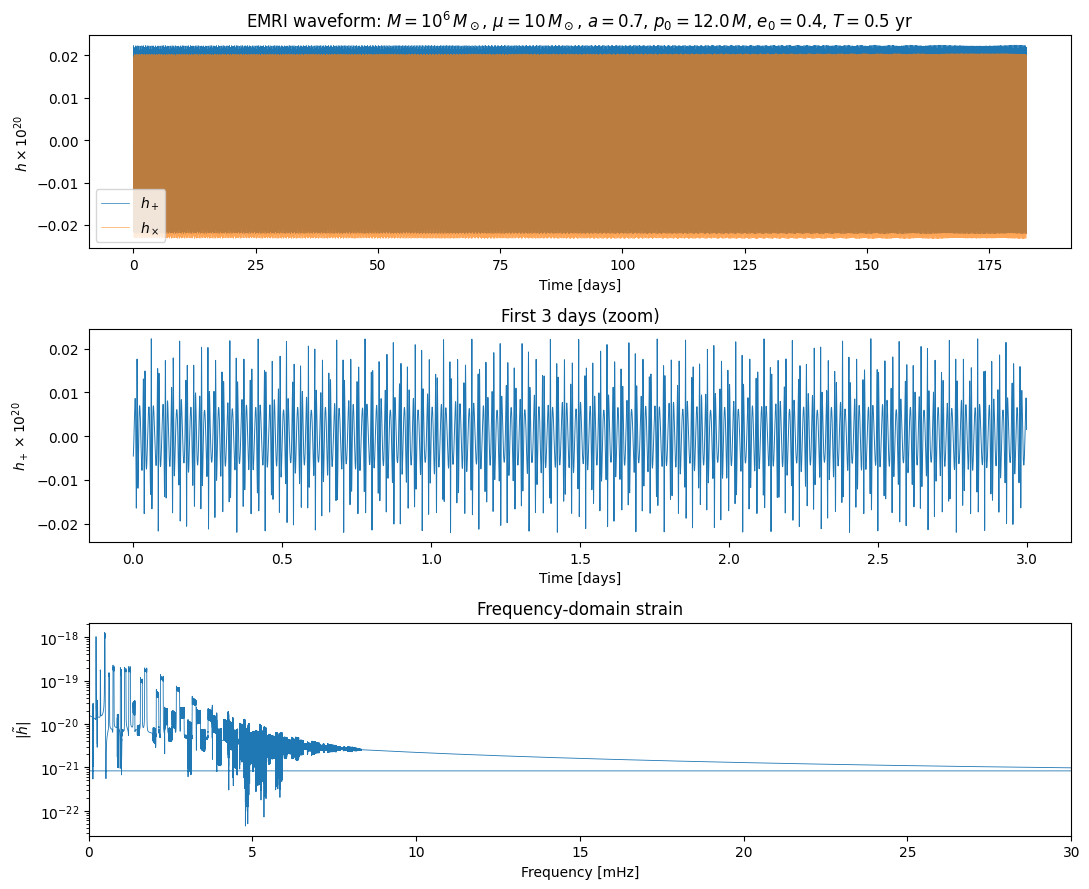

In [3]:
from fewtrax.summation.modes import to_frequency_domain

freqs, h_tilde = to_frequency_domain(hp + 1j * hx, dt=params["dt"])

fig, axes = plt.subplots(3, 1, figsize=(11, 9))

t_days = t_arr / 86400.0
scale  = 1e20

axes[0].plot(t_days, np.asarray(hp) * scale, lw=0.5, label="$h_+$", color="C0")
axes[0].plot(t_days, np.asarray(hx) * scale, lw=0.5, label="$h_\\times$", color="C1", alpha=0.7)
axes[0].set_xlabel("Time [days]")
axes[0].set_ylabel(f"$h \\times 10^{{{int(np.log10(scale))}}}$")
axes[0].set_title(
    fr"EMRI waveform: $M=10^6\,M_\odot$, $\mu=10\,M_\odot$, $a={params['a']}$, "
    fr"$p_0={params['p0']}\,M$, $e_0={params['e0']}$, $T=0.5$ yr"
)
axes[0].legend()

# Zoom into first 3 days to see individual oscillations
mask_zoom = t_days < 3
axes[1].plot(t_days[mask_zoom], np.asarray(hp)[mask_zoom] * scale, lw=0.7)
axes[1].set_xlabel("Time [days]")
axes[1].set_ylabel(f"$h_+ \\times 10^{{{int(np.log10(scale))}}}$")
axes[1].set_title("First 3 days (zoom)")

f_mHz = np.asarray(freqs) * 1000
axes[2].semilogy(f_mHz, np.asarray(jnp.abs(h_tilde)), lw=0.6)
axes[2].set_xlabel("Frequency [mHz]")
axes[2].set_ylabel(r"$|\tilde{h}|$")
axes[2].set_title("Frequency-domain strain")
axes[2].set_xlim([0, 30])

plt.tight_layout()
plt.show()

## 5.2  Harmonic Frequency Tracks

Each mode $(\ell, m, k, n)$ contributes a spectral line at the instantaneous frequency

$$
f_{mkn}(t) = \frac{m\,\Omega_\phi(t) + k\,\Omega_\theta(t) + n\,\Omega_r(t)}{2\pi}
$$

As the orbit inspirals these frequencies *chirp* upward, producing the characteristic EMRI frequency track.  These tracks are the key observable for LISA data analysis.

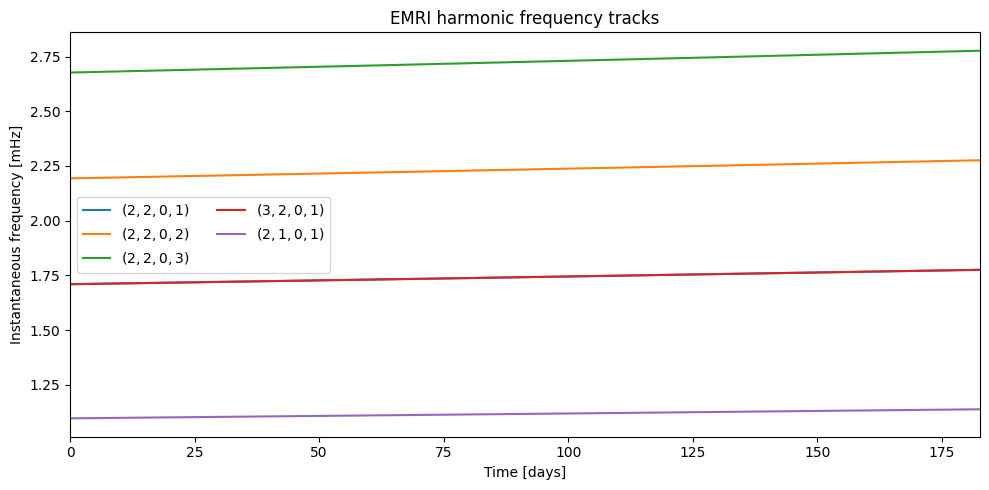

In [4]:
track_modes = [
    (2, 2, 0, 1), (2, 2, 0, 2), (2, 2, 0, 3),
    (3, 2, 0, 1), (2, 1, 0, 1),
]

fig, ax = plt.subplots(figsize=(10, 5))

for (l, m, k, n) in track_modes:
    t_tr, f_tr = wf.get_harmonic_track(
        l=l, m=m, k=k, n=n,
        M=params["M"], mu=params["mu"], a=params["a"],
        p0=params["p0"], e0=params["e0"], T=params["T"],
    )
    t_days_tr = np.asarray(t_tr) / 86400.0
    f_mHz_tr  = np.asarray(f_tr) * 1000
    valid_tr  = np.isfinite(f_mHz_tr) & (f_mHz_tr > 0)
    ax.plot(t_days_tr[valid_tr], f_mHz_tr[valid_tr],
            label=fr"$({l},{m},{k},{n})$", lw=1.5)

ax.set_xlabel("Time [days]")
ax.set_ylabel("Instantaneous frequency [mHz]")
ax.set_title("EMRI harmonic frequency tracks")
ax.legend(ncol=2)
ax.set_xlim([0, t_days[-1]])
plt.tight_layout()
plt.show()

## 5.3  Parameter Variation

### Effect of Spin $a$

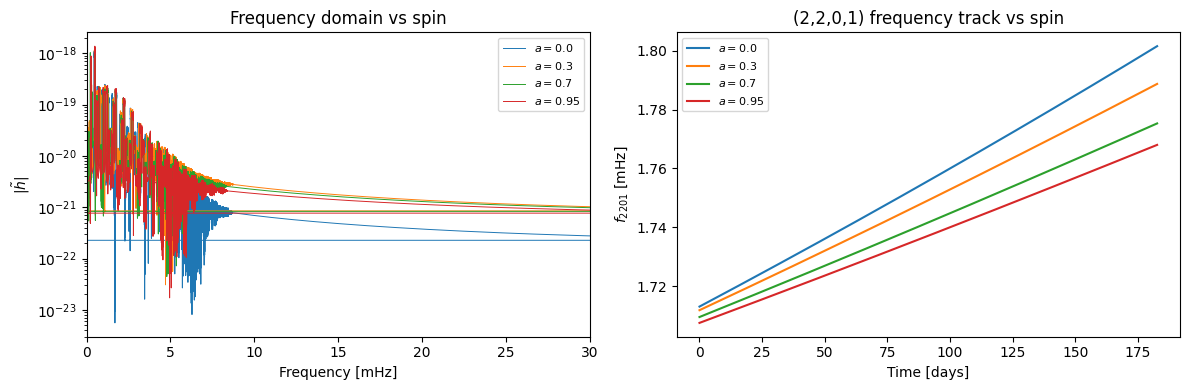

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for a_val in [0.0, 0.3, 0.7, 0.95]:
    hp_a, hx_a = wf(**{**params, "a": a_val})
    freqs_a, ht_a = to_frequency_domain(hp_a + 1j * hx_a, dt=10.0)
    
    axes[0].semilogy(np.asarray(freqs_a)*1e3, np.asarray(jnp.abs(ht_a)),
                     lw=0.7, label=f"$a={a_val}$")

    t_tr, f_tr = wf.get_harmonic_track(2, 2, 0, 1, M=params["M"], mu=params["mu"],
                                         a=a_val, p0=params["p0"], e0=params["e0"], T=params["T"])
    t_d = np.asarray(t_tr) / 86400
    f_m = np.asarray(f_tr) * 1e3
    ok  = np.isfinite(f_m) & (f_m > 0)
    axes[1].plot(t_d[ok], f_m[ok], label=f"$a={a_val}$")

axes[0].set_xlim([0, 30])
axes[0].set_xlabel("Frequency [mHz]")
axes[0].set_ylabel(r"$|\tilde{h}|$")
axes[0].set_title("Frequency domain vs spin")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Time [days]")
axes[1].set_ylabel("$f_{2201}$ [mHz]")
axes[1].set_title("(2,2,0,1) frequency track vs spin")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Effect of Initial Eccentricity $e_0$

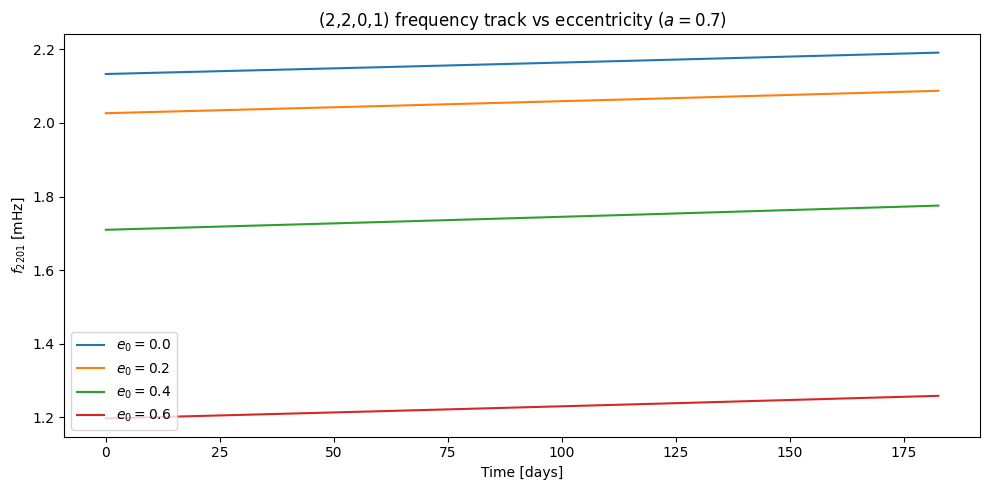

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for e0_val in [0.0, 0.2, 0.4, 0.6]:
    t_tr, f_tr = wf.get_harmonic_track(2, 2, 0, 1, M=params["M"], mu=params["mu"],
                                         a=params["a"], p0=params["p0"],
                                         e0=e0_val, T=params["T"])
    t_d = np.asarray(t_tr) / 86400
    f_m = np.asarray(f_tr) * 1e3
    ok  = np.isfinite(f_m) & (f_m > 0)
    ax.plot(t_d[ok], f_m[ok], label=f"$e_0={e0_val}$")

ax.set_xlabel("Time [days]")
ax.set_ylabel("$f_{2201}$ [mHz]")
ax.set_title("(2,2,0,1) frequency track vs eccentricity ($a=0.7$)")
ax.legend()
plt.tight_layout()
plt.show()

## 5.4  Inspecting the Sparse Pipeline

`generate_sparse` exposes the intermediate trajectory and amplitude arrays, useful for debugging or building custom summation schemes.

In [7]:
sparse = wf.generate_sparse(**{k: v for k, v in params.items()
                               if k not in ("dist", "qS", "phiS", "qK", "phiK",
                                            "Phi_phi0", "Phi_theta0", "Phi_r0")})

print("Sparse output keys:", list(sparse.keys()))
print(f"Trajectory length   : {len(sparse['p'])} points")
print(f"Selected modes      : {len(sparse['mode_inds'])}")
print(f"teuk_modes shape    : {sparse['teuk_modes'].shape}  (N_traj × N_modes)")

Sparse output keys: ['t', 'p', 'e', 'Phi_phi', 'Phi_theta', 'Phi_r', 'teuk_modes', 'l_arr', 'm_arr', 'k_arr', 'n_arr', 'mode_inds']
Trajectory length   : 150 points
Selected modes      : 89
teuk_modes shape    : (150, 89)  (N_traj × N_modes)


## 5.5  Sky-Angle Dependence

The observed strain $h_+$ depends on sky angles $(\theta_S, \phi_S)$ and spin orientation $(\theta_K, \phi_K)$ through the pattern functions.  For an isotropic source the SNR should average appropriately over sky position.

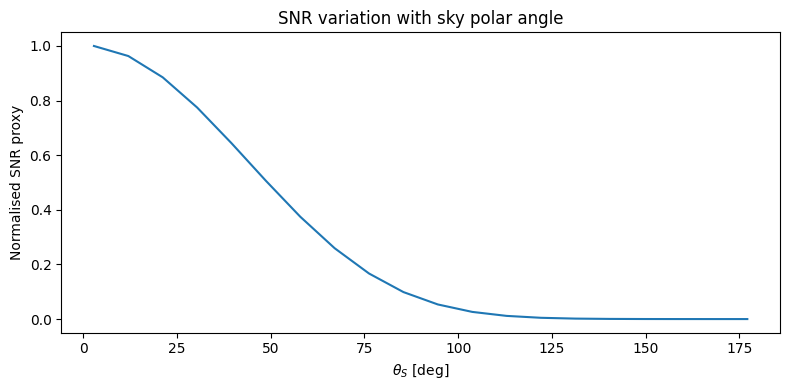

In [8]:
from fewtrax.utils.harmonics import get_ylms_for_modes

theta_vals = np.linspace(0.05, np.pi - 0.05, 20)
snr_proxy  = []

l_sel = sparse["l_arr"]
m_sel = sparse["m_arr"]

for th in theta_vals:
    ylms_p, _ = get_ylms_for_modes(l_sel, m_sel, float(th), 0.5)
    # SNR proxy: sum |Y * A|^2 over modes and trajectory
    power = float(jnp.sum(jnp.abs(ylms_p)**2 * jnp.mean(jnp.abs(jnp.asarray(sparse["teuk_modes"]))**2, axis=0)))
    snr_proxy.append(power)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.degrees(theta_vals), np.array(snr_proxy) / max(snr_proxy))
ax.set_xlabel(r"$\theta_S$ [deg]")
ax.set_ylabel("Normalised SNR proxy")
ax.set_title("SNR variation with sky polar angle")
plt.tight_layout()
plt.show()

## Summary

The `KerrEccentricEquatorialWaveform` class:

| Method | Description |
|---|---|
| `__init__(data_dir, ...)` | Loads flux and amplitude data; builds trajectory + summation objects |
| `__call__(M, μ, a, p₀, e₀, ...)` | Returns `(hp, hx)` with full FEW-compatible API |
| `generate_sparse(...)` | Returns trajectory dict with amplitudes; useful for custom pipelines |
| `get_harmonic_track(l, m, k, n, ...)` | Computes instantaneous frequency track for a single mode |

**Next:** [06_jax_features.ipynb](06_jax_features.ipynb) — JIT compilation, vmap batching, and automatic differentiation for parameter estimation.